In [1]:
%pip install ultralytics
%pip install opencv-python
%pip install mediapipe
%pip install wandb
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import wandb

wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/amber/.netrc.
wandb: Currently logged in as: amberchee (amberchee-xiamen-university-malaysia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms

# Utilities for training a hazard classification model using PyTorch.


In [4]:
wandb.init(
    project="hazard_classification",
    name="efficientnet_v1"
)

In [5]:
DATASET_PATH = "/Users/amber/Desktop/hackathon/hazard_dataset"
batch_size = 32
epochs = 30
lr = 0.001

In [6]:
# Dataset Preprocessing

def get_transformed():
  """Returns the training and validation transforms for the dataset."""
  train_transformed = transforms.Compose([
      transforms.Resize((224, 224)),
      transforms.RandomHorizontalFlip(p=0.5),
      transforms.RandomRotation(15),
      transforms.ColorJitter(
          brightness=0.2,
          contrast=0.2,
          saturation=0.2,
          hue=0.05
      ),

      transforms.ToTensor(),

      transforms.Normalize(
          mean=[0.485, 0.456, 0.406],
          std=[0.229, 0.224, 0.225]
      )
  ])

  val_transformed = transforms.Compose([
      transforms.Resize((224, 224)),
      transforms.ToTensor(),
      transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
  ])

  return train_transformed, val_transformed

In [7]:
# Load & Split Dataset

def load_datasets(data_path):
  """Loads the dataset from the given path and splits it into training, validation, and test sets."""
  train_t, val_t = get_transformed()

  full_dataset = datasets.ImageFolder(data_path, transform=train_t)
  class_labels = full_dataset.classes

  print("Classes: ", class_labels)
  print("Total Images: ", len(full_dataset))
  print("Class index mapping:", full_dataset.class_to_idx)

  total = len(full_dataset)
  train_size = int(0.8 * total)
  val_size = int(0.1 * total)
  test_size = total - train_size - val_size

  train_ds, val_ds, test_ds = random_split(full_dataset, [train_size, val_size, test_size])

  val_ds.dataset.transform = val_t
  test_ds.dataset.transform = val_t

  train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
  val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
  test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

  return train_loader, val_loader, test_loader, class_labels


In [8]:
def build_efficientnet(num_classes, device):
  """Builds an EfficientNet model with the specified number of output classes and moves it to the given device."""
  model = models.efficientnet_b0(pretrained=True)
  in_features = model.classifier[1].in_features
  model.classifier[1] = nn.Linear(in_features, num_classes)
  model = model.to(device)
  return model

In [9]:
def train_model(model, train_loader, val_loader, device, epochs=30, lr=0.001, patience=5):
    """Trains the given model using the provided training and validation data loaders, with early stopping based on validation loss."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    best_val_loss = float("inf")
    patience_counter = 0

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        model.train()
        train_correct = 0
        train_total = 0
        train_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            _, preds = outputs.max(1)
            train_total += labels.size(0)
            train_correct += preds.eq(labels).sum().item()

        train_acc = train_correct / train_total
        train_loss = train_loss / len(train_loader)

        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)

                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, preds = outputs.max(1)
                val_total += labels.size(0)
                val_correct += preds.eq(labels).sum().item()

        val_acc = val_correct / val_total
        val_loss = val_loss / len(val_loader)

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        wandb.log({
            "epoch": epoch+1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc
        })

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pth")
            print("Best model saved")

        else:
            patience_counter += 1
            print(f"No improvement ({patience_counter}/{patience})")

        if patience_counter >= patience:
            print(f"Early stop at epoch {epoch+1}")
            break

    return train_losses, val_losses, train_accs, val_accs

In [10]:
def evaluate_model(
    model,
    test_loader,
    device,
    class_names,
    model_path="/Users/amber/Desktop/hackathon/disaster-readiness/ai/classification/notebook/best_model.pth"
):
    """Model Evaluation on the test set, including accuracy, classification report, and confusion matrix."""
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    criterion = nn.CrossEntropyLoss()

    total = 0
    correct = 0
    total_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, preds = outputs.max(1)

            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = correct / total
    test_loss = total_loss / len(test_loader)

    print(f"Test Accuracy : {test_acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))


    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.show()

    return test_acc, test_loss

In [11]:
def accuracyloss_curves(train_losses, val_losses, train_accs, val_accs):
    """Plots accuracy and loss curves for training and validation sets."""
    epochs_range = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs_range, train_losses, marker="o", label="Train Loss")
    plt.plot(epochs_range, val_losses, marker="o", label="Validation Loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1,2,2)
    plt.plot(epochs_range, train_accs, marker="o", label="Train Accuracy")
    plt.plot(epochs_range, val_accs, marker="o", label="Validation Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

Using Apple MPS GPU
Classes:  ['fire', 'flood', 'landslide', 'normal']
Total Images:  2110
Class index mapping: {'fire': 0, 'flood': 1, 'landslide': 2, 'normal': 3}
Classes: ['fire', 'flood', 'landslide', 'normal']


/Users/amber/miniconda3/envs/tf310/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/amber/miniconda3/envs/tf310/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/30 | Train Acc: 0.9105 | Train Loss: 0.2855 | Val Loss: 0.1759 | Val Acc: 0.9526
Best model saved
Epoch 2/30 | Train Acc: 0.9716 | Train Loss: 0.0848 | Val Loss: 0.2107 | Val Acc: 0.9479
No improvement (1/5)
Epoch 3/30 | Train Acc: 0.9787 | Train Loss: 0.0621 | Val Loss: 0.0822 | Val Acc: 0.9763
Best model saved
Epoch 4/30 | Train Acc: 0.9840 | Train Loss: 0.0585 | Val Loss: 0.0568 | Val Acc: 0.9810
Best model saved
Epoch 5/30 | Train Acc: 0.9781 | Train Loss: 0.0562 | Val Loss: 0.0680 | Val Acc: 0.9763
No improvement (1/5)
Epoch 6/30 | Train Acc: 0.9781 | Train Loss: 0.0755 | Val Loss: 0.1025 | Val Acc: 0.9621
No improvement (2/5)
Epoch 7/30 | Train Acc: 0.9816 | Train Loss: 0.0567 | Val Loss: 0.1364 | Val Acc: 0.9716
No improvement (3/5)
Epoch 8/30 | Train Acc: 0.9852 | Train Loss: 0.0386 | Val Loss: 0.1138 | Val Acc: 0.9763
No improvement (4/5)
Epoch 9/30 | Train Acc: 0.9905 | Train Loss: 0.0281 | Val Loss: 0.1302 | Val Acc: 0.9716
No improvement (5/5)
Early stop at epoch 9


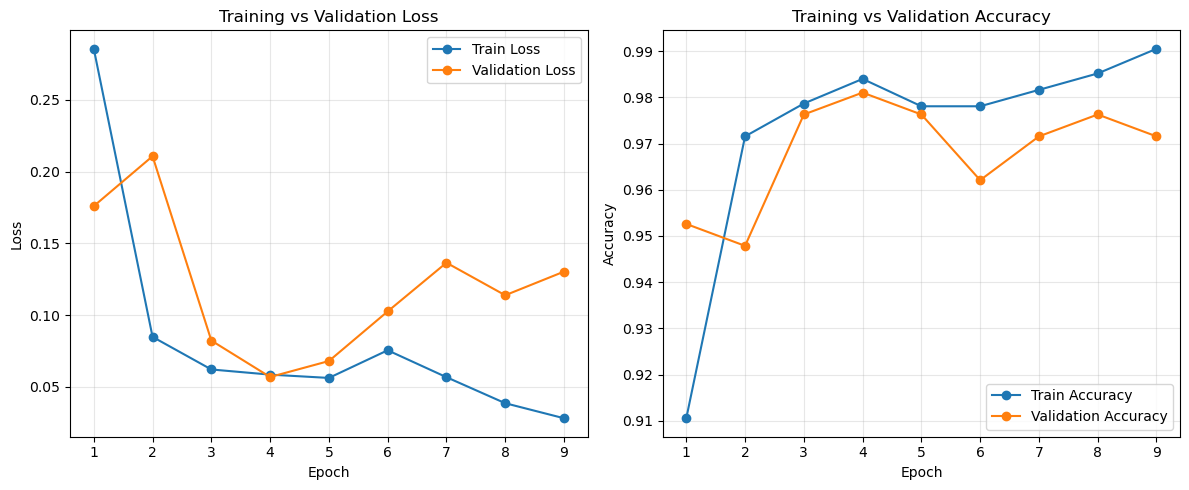

Test Accuracy : 0.9953

Classification Report:
              precision    recall  f1-score   support

        fire     1.0000    1.0000    1.0000        55
       flood     0.9836    1.0000    0.9917        60
   landslide     1.0000    1.0000    1.0000        32
      normal     1.0000    0.9844    0.9921        64

    accuracy                         0.9953       211
   macro avg     0.9959    0.9961    0.9960       211
weighted avg     0.9953    0.9953    0.9953       211



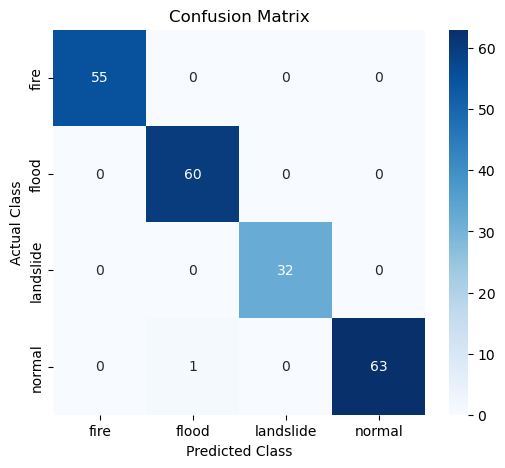

In [12]:
def main():
    """Main function to execute the training and evaluation pipeline for the hazard classification model."""
    wandb.init(project="hazard-classifier", name = "version4")

    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using Apple MPS GPU")

    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print("Using CUDA GPU")

    else:
        device = torch.device("cpu")
        print("Using CPU")

    train_loader, val_loader, test_loader, class_names = load_datasets(DATASET_PATH)

    print(f"Classes: {class_names}")

    model = build_efficientnet(len(class_names), device)
    model = model.to(device).float()

    train_losses, val_losses, train_accs, val_accs = train_model(
        model,
        train_loader,
        val_loader,
        device
    )

    accuracyloss_curves(train_losses, val_losses, train_accs, val_accs)

    evaluate_model(
        model,
        test_loader,
        device,
        class_names,
        model_path= "/Users/amber/Desktop/hackathon/disaster-readiness/ai/classification/notebook/best_model.pth"
    )

if __name__ == "__main__":
    main()

In [13]:
print()